<a href="https://colab.research.google.com/github/carraci/ai-Practical/blob/main/6_to_10_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

6) Adaboost Ensemble Learning


ADABOOST ENSEMBLE LEARNING
Dataset Size: (1372, 5)
Number of Weak Classifiers: 50
Weak Classifier: Decision Stump
Accuracy: 100.0 %

Class Distribution:
class
0    762
1    610
Name: count, dtype: int64


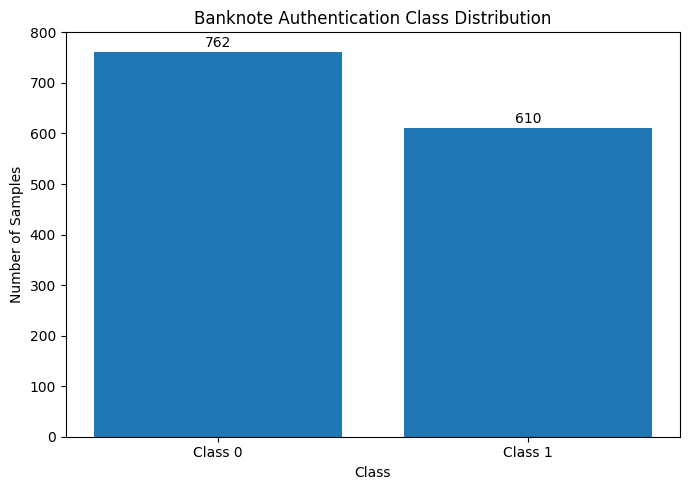

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


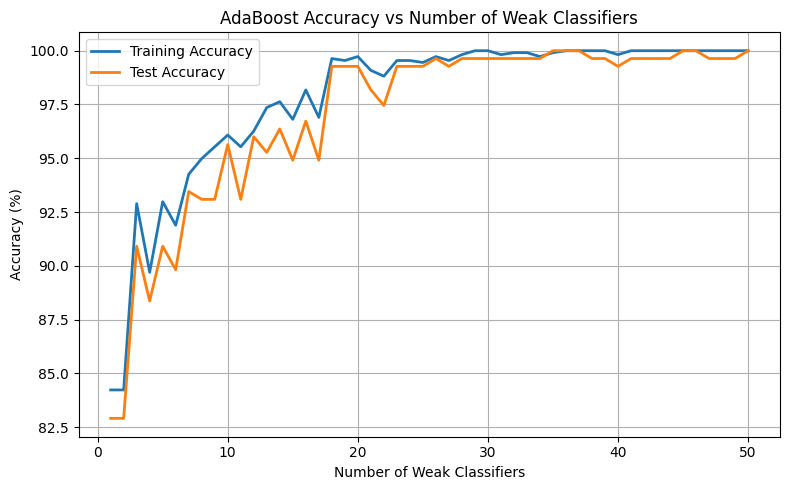

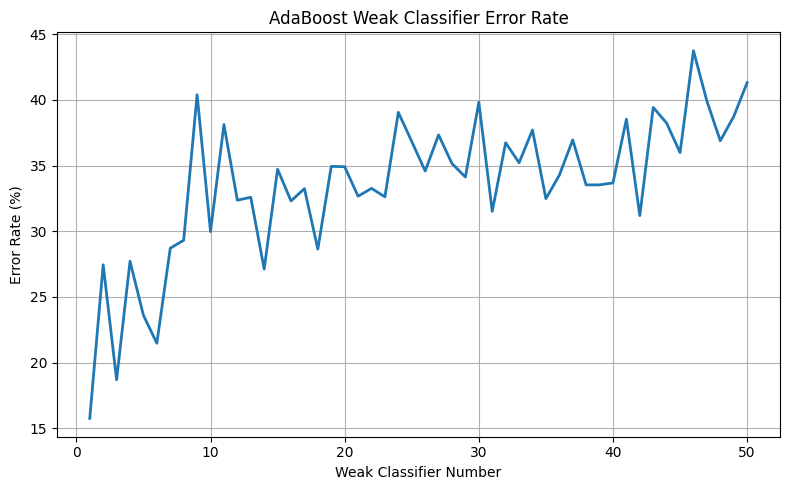

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

columns = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

X = df.drop("class", axis=1)
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

model = AdaBoostClassifier(
    estimator=weak_classifier,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("ADABOOST ENSEMBLE LEARNING")
print("=" * 35)
print("Dataset Size:", df.shape)
print("Number of Weak Classifiers:", model.n_estimators)
print("Weak Classifier: Decision Stump")
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClass Distribution:")
print(df["class"].value_counts())

plt.figure(figsize=(7, 5))

counts = df["class"].value_counts().sort_index()

bars = plt.bar(
    ["Class 0", "Class 1"],
    counts.values
)

plt.title("Banknote Authentication Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 10,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

train_accuracy = []
test_accuracy = []

for prediction in model.staged_predict(X_train):
    train_accuracy.append(
        accuracy_score(y_train, prediction)
    )

for prediction in model.staged_predict(X_test):
    test_accuracy.append(
        accuracy_score(y_test, prediction)
    )

estimators = range(1, len(test_accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    estimators,
    np.array(train_accuracy) * 100,
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    estimators,
    np.array(test_accuracy) * 100,
    linewidth=2,
    label="Test Accuracy"
)

plt.xlabel("Number of Weak Classifiers")
plt.ylabel("Accuracy (%)")
plt.title("AdaBoost Accuracy vs Number of Weak Classifiers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    estimators,
    np.array(model.estimator_errors_) * 100,
    linewidth=2
)

plt.xlabel("Weak Classifier Number")
plt.ylabel("Error Rate (%)")
plt.title("AdaBoost Weak Classifier Error Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

Train the ensemble model on a given dataset and evaluate its performance.



Dataset Shape: (1372, 5)
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

AdaBoost Ensemble Performance
--------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


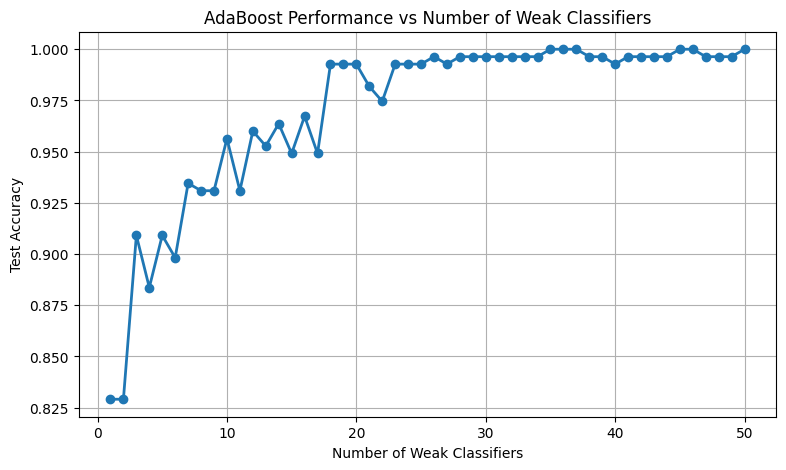

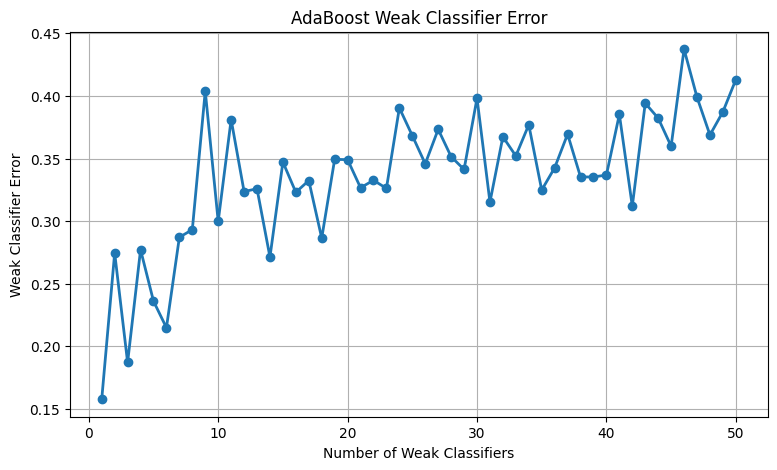

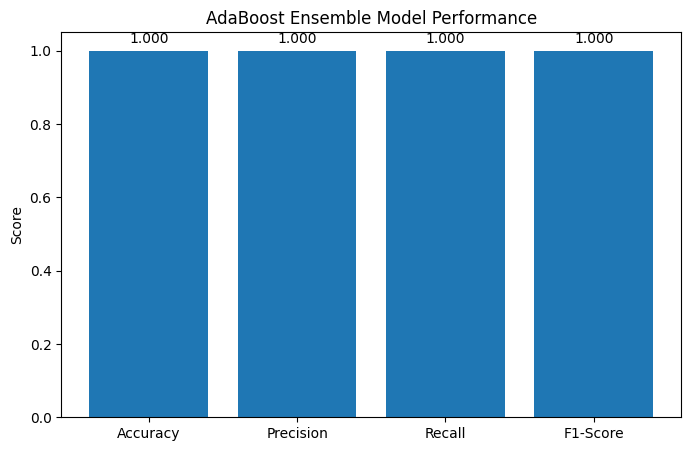

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]

df = pd.read_csv(url, header=None, names=columns)

print("Dataset Shape:", df.shape)
print(df.head())

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

model = AdaBoostClassifier(
    estimator=weak_classifier,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAdaBoost Ensemble Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

staged_accuracy = []

for prediction in model.staged_predict(X_test):
    staged_accuracy.append(
        accuracy_score(y_test, prediction)
    )

estimators = range(1, len(staged_accuracy) + 1)

plt.figure(figsize=(9, 5))
plt.plot(estimators, staged_accuracy, marker="o", linewidth=2)
plt.xlabel("Number of Weak Classifiers")
plt.ylabel("Test Accuracy")
plt.title("AdaBoost Performance vs Number of Weak Classifiers")
plt.grid(True)
plt.show()

errors = np.asarray(model.estimator_errors_)[:len(staged_accuracy)]

plt.figure(figsize=(9, 5))
plt.plot(
    estimators,
    errors,
    marker="o",
    linewidth=2
)
plt.xlabel("Number of Weak Classifiers")
plt.ylabel("Weak Classifier Error")
plt.title("AdaBoost Weak Classifier Error")
plt.grid(True)
plt.show()

metrics = [accuracy, precision, recall, f1]
names = ["Accuracy", "Precision", "Recall", "F1-Score"]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, metrics)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("AdaBoost Ensemble Model Performance")

for bar, value in zip(bars, metrics):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.show()

Compare the results with individual weak classifiers.


Performance Comparison
   Metric  Individual Weak Classifier  AdaBoost Ensemble
 Accuracy                    0.829091                1.0
Precision                    0.748344                1.0
   Recall                    0.926230                1.0
 F1-Score                    0.827839                1.0

Improvement by AdaBoost
Accuracy: 0.1709
Precision: 0.2517
Recall: 0.0738
F1-Score: 0.1722


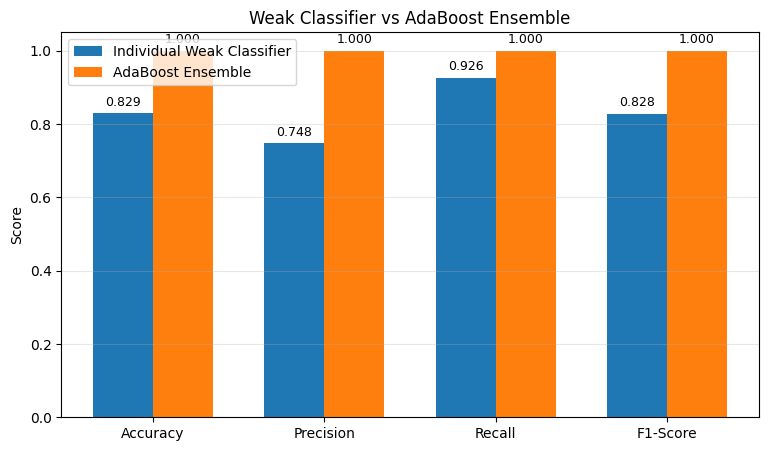

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

columns = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]

df = pd.read_csv(url, header=None, names=columns)

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

weak_classifier = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

weak_classifier.fit(X_train, y_train)

weak_pred = weak_classifier.predict(X_test)

weak_accuracy = accuracy_score(y_test, weak_pred)
weak_precision = precision_score(y_test, weak_pred)
weak_recall = recall_score(y_test, weak_pred)
weak_f1 = f1_score(y_test, weak_pred)

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

adaboost.fit(X_train, y_train)

ada_pred = adaboost.predict(X_test)

ada_accuracy = accuracy_score(y_test, ada_pred)
ada_precision = precision_score(y_test, ada_pred)
ada_recall = recall_score(y_test, ada_pred)
ada_f1 = f1_score(y_test, ada_pred)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Individual Weak Classifier": [
        weak_accuracy,
        weak_precision,
        weak_recall,
        weak_f1
    ],
    "AdaBoost Ensemble": [
        ada_accuracy,
        ada_precision,
        ada_recall,
        ada_f1
    ]
})

print("\nPerformance Comparison")
print("======================")
print(results.to_string(index=False))

print("\nImprovement by AdaBoost")
print("======================")

for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    weak_value = results.loc[
        results["Metric"] == metric,
        "Individual Weak Classifier"
    ].iloc[0]

    ada_value = results.loc[
        results["Metric"] == metric,
        "AdaBoost Ensemble"
    ].iloc[0]

    print(f"{metric}: {(ada_value - weak_value):.4f}")

plt.figure(figsize=(9, 5))

x = range(len(results["Metric"]))
width = 0.35

plt.bar(
    [i - width/2 for i in x],
    results["Individual Weak Classifier"],
    width=width,
    label="Individual Weak Classifier"
)

plt.bar(
    [i + width/2 for i in x],
    results["AdaBoost Ensemble"],
    width=width,
    label="AdaBoost Ensemble"
)

plt.xticks(x, results["Metric"])
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Weak Classifier vs AdaBoost Ensemble")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i in x:
    weak = results["Individual Weak Classifier"].iloc[i]
    ada = results["AdaBoost Ensemble"].iloc[i]

    plt.text(i - width/2, weak + 0.02, f"{weak:.3f}",
             ha="center", fontsize=9)

    plt.text(i + width/2, ada + 0.02, f"{ada:.3f}",
             ha="center", fontsize=9)

plt.show()

7 ) Naive Bayes’ Classifier

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Naive Bayes Classification
---------------------------
Training Samples: 614
Testing Samples: 154
Accuracy: 70.78 %

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.74      0.77       100
    Diabetic       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



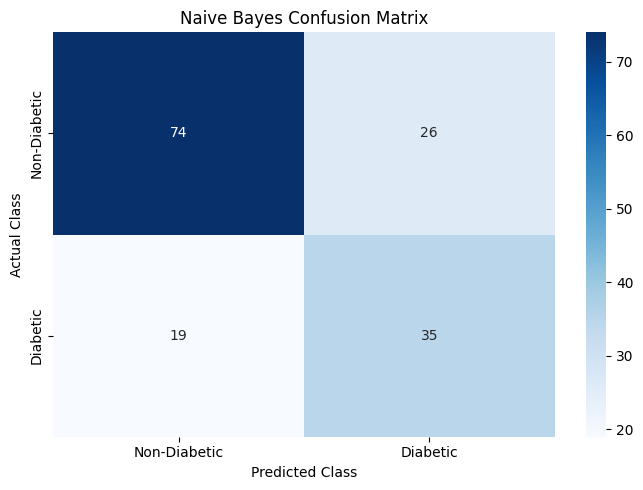

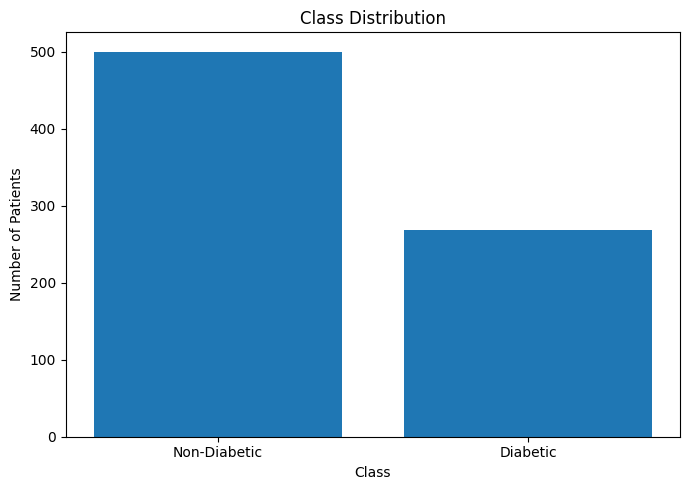

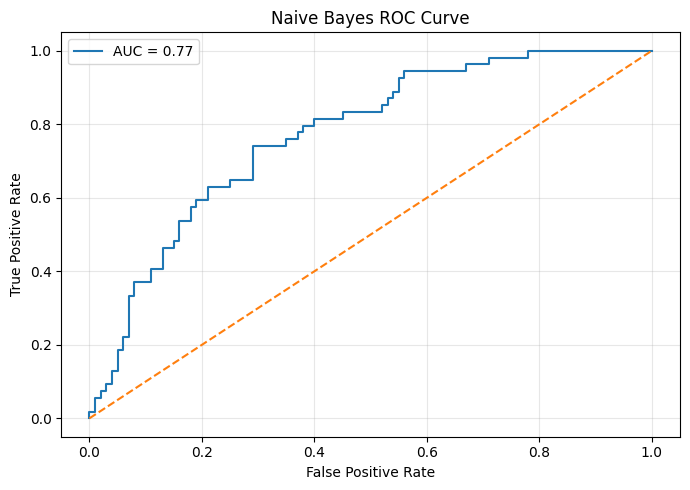

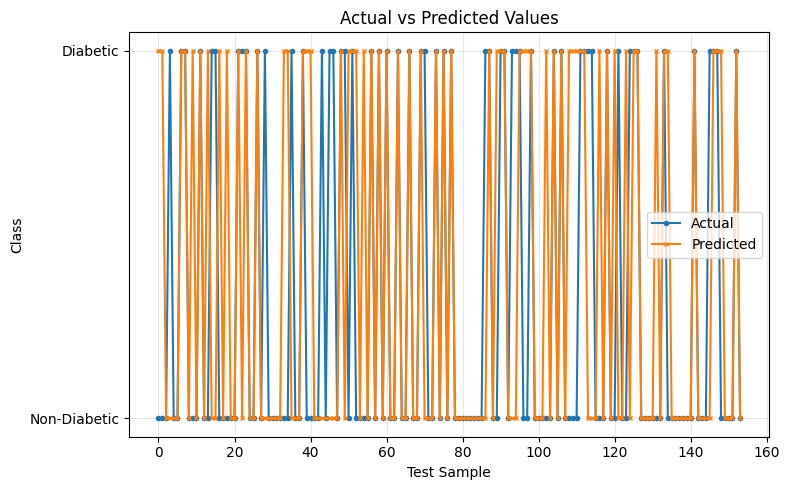


Model Performance
-----------------
Accuracy : 70.78 %
ROC-AUC  : 0.77


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset Shape:", df.shape)
display(df.head())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Classification")
print("---------------------------")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Diabetic", "Diabetic"]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Non-Diabetic", "Diabetic"],
    [sum(y == 0), sum(y == 1)]
)
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    range(len(y_test)),
    y_test.values,
    label="Actual",
    marker="o",
    markersize=3
)
plt.plot(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    marker="x",
    markersize=3
)
plt.xlabel("Test Sample")
plt.ylabel("Class")
plt.title("Actual vs Predicted Values")
plt.yticks([0, 1], ["Non-Diabetic", "Diabetic"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nModel Performance")
print("-----------------")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("ROC-AUC  :", round(auc, 2))

Train a Naive Bayes’ model using a given dataset and calculate class
probabilities.

Naive Bayes Model Trained Successfully
Training Samples: 614
Testing Samples: 154

Class Probabilities:
P(Class = 0 | Features) = Non-Diabetic
P(Class = 1 | Features) = Diabetic


,Actual Class,Predicted Class,Non-Diabetic Probability,Diabetic Probability
0,0,1,0.484066,0.515934
1,0,1,0.497202,0.502798
2,0,0,0.795069,0.204931
3,1,0,0.870000,0.130000
4,0,0,0.994131,0.005869
5,0,0,0.918032,0.081968
6,1,1,0.371638,0.628362
7,1,1,0.008058,0.991942
8,0,0,0.981764,0.018236
9,0,1,0.047122,0.952878



Prior Class Probabilities:
Non-Diabetic: 0.6515
Diabetic: 0.3485

Accuracy: 70.78 %


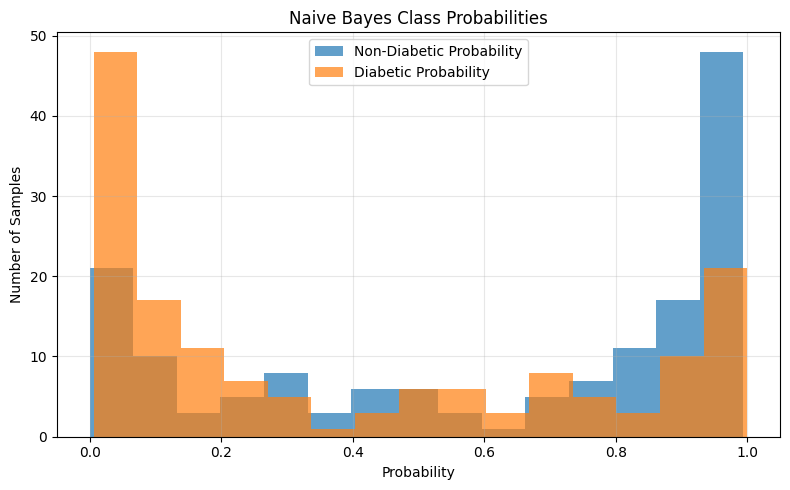

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
probabilities = model.predict_proba(X_test)

print("Naive Bayes Model Trained Successfully")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nClass Probabilities:")
print("P(Class = 0 | Features) = Non-Diabetic")
print("P(Class = 1 | Features) = Diabetic")

results = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred,
    "Non-Diabetic Probability": probabilities[:, 0],
    "Diabetic Probability": probabilities[:, 1]
})

display(results.head(10))

print("\nPrior Class Probabilities:")
print("Non-Diabetic:", round(model.class_prior_[0], 4))
print("Diabetic:", round(model.class_prior_[1], 4))

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

plt.figure(figsize=(8, 5))

plt.hist(
    probabilities[:, 0],
    bins=15,
    alpha=0.7,
    label="Non-Diabetic Probability"
)

plt.hist(
    probabilities[:, 1],
    bins=15,
    alpha=0.7,
    label="Diabetic Probability"
)

plt.xlabel("Probability")
plt.ylabel("Number of Samples")
plt.title("Naive Bayes Class Probabilities")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Evaluate the accuracy of the model on test data and analyze the results.

Naive Bayes Model Evaluation
Test Accuracy: 70.78 %

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.74      0.77       100
    Diabetic       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



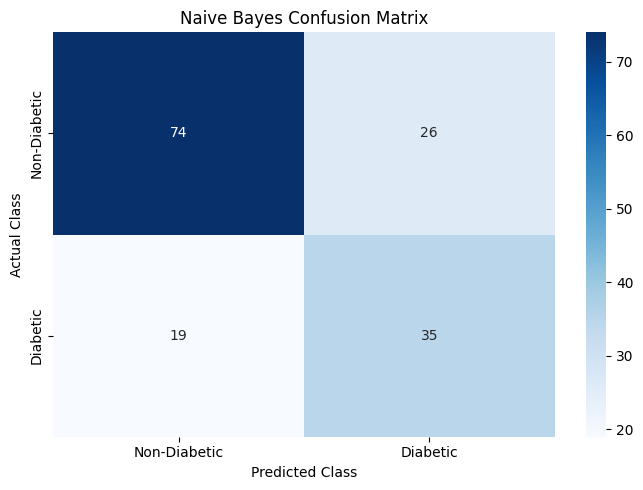

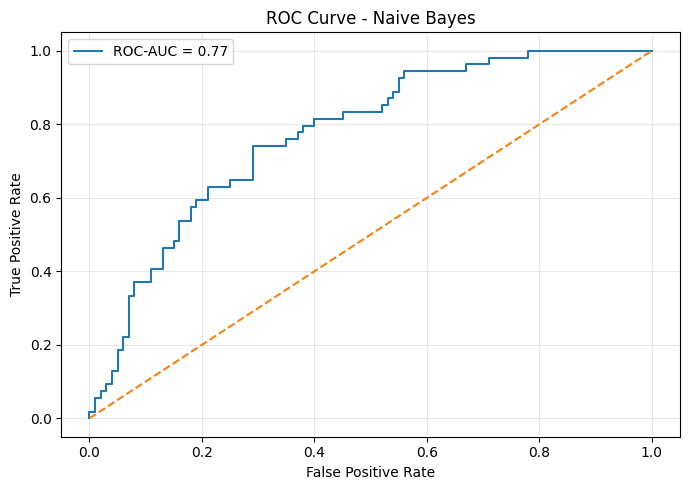

ROC-AUC Score: 0.77


In [8]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("Naive Bayes Model Evaluation")
print("============================")
print("Test Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Diabetic", "Diabetic"]
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", round(auc, 2))

8 ) K-Nearest Neighbors (K-NN)

Implement the K-NN algorithm for classification or regression.

Dataset Shape: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8      

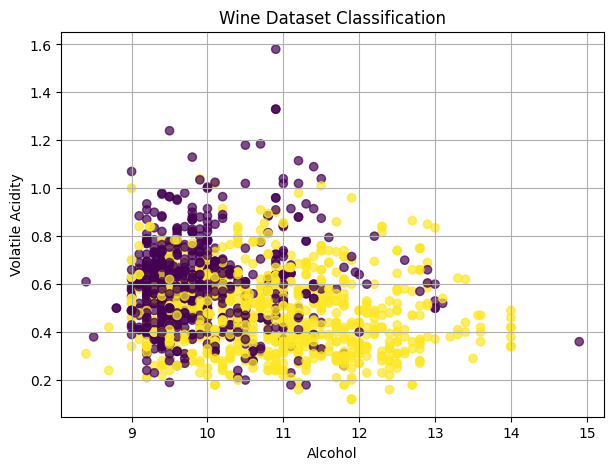

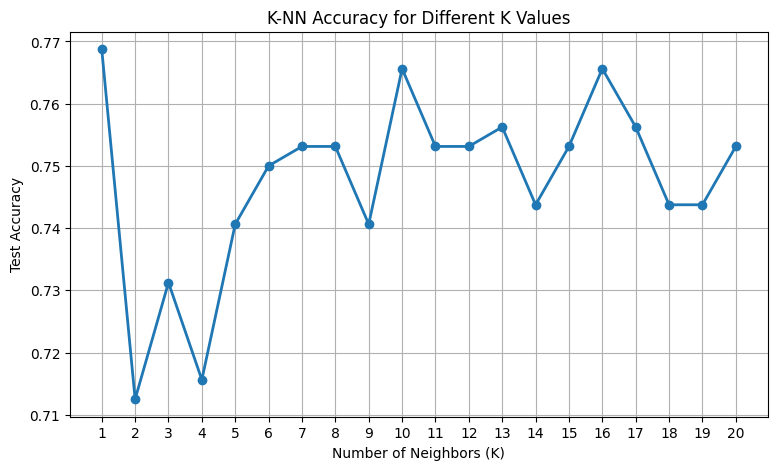

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

print("Dataset Shape:", df.shape)
print(df.head())

df["quality"] = (df["quality"] >= 6).astype(int)

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nK-NN Classification Results")
print("============================")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

plt.figure(figsize=(7, 5))

plt.scatter(
    df["alcohol"],
    df["volatile acidity"],
    c=df["quality"],
    alpha=0.7
)

plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.title("Wine Dataset Classification")
plt.grid(True)
plt.show()

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, prediction))

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy")
plt.title("K-NN Accuracy for Different K Values")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

Apply the K-NN algorithm to a given dataset and predict the class or value
for test data.

K-NN Test Data Predictions
 Actual Class  Predicted Class
            1                1
            0                1
            0                0
            0                1
            1                1
            1                1
            0                0
            0                0
            1                1
            1                1
            0                0
            1                0
            0                0
            0                0
            0                0
            1                0
            1                0
            0                1
            1                1
            0                0

Accuracy: 0.7406

Classification Report
              precision    recall  f1-score   support

    Not Good       0.72      0.72      0.72       149
        Good       0.76      0.75      0.76       171

    accuracy                           0.74       320
   macro avg       0.74      0.74      0.74       320
weighted 

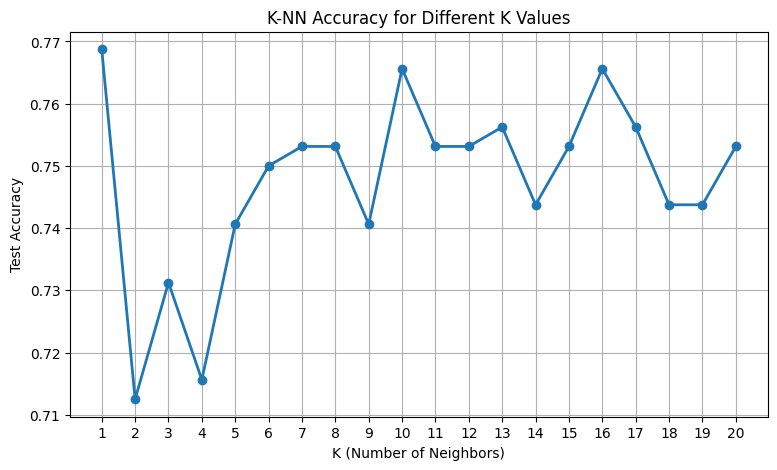

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

df["quality"] = (df["quality"] >= 6).astype(int)

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("K-NN Test Data Predictions")
print("==========================")

prediction_table = pd.DataFrame({
    "Actual Class": y_test.values,
    "Predicted Class": y_pred
})

print(prediction_table.head(20).to_string(index=False))

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Good", "Good"]
))

plt.figure(figsize=(9, 5))

plt.plot(
    range(1, 21),
    [
        accuracy_score(
            y_test,
            KNeighborsClassifier(n_neighbors=k)
            .fit(X_train, y_train)
            .predict(X_test)
        )
        for k in range(1, 21)
    ],
    marker="o",
    linewidth=2
)

plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("K-NN Accuracy for Different K Values")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

Evaluate the accuracy or error of the predictions and analyze the results.

K-NN Performance Evaluation
Accuracy   : 0.7406
Error Rate : 0.2594
Precision  : 0.7588
Recall     : 0.7544
F1-Score   : 0.7566


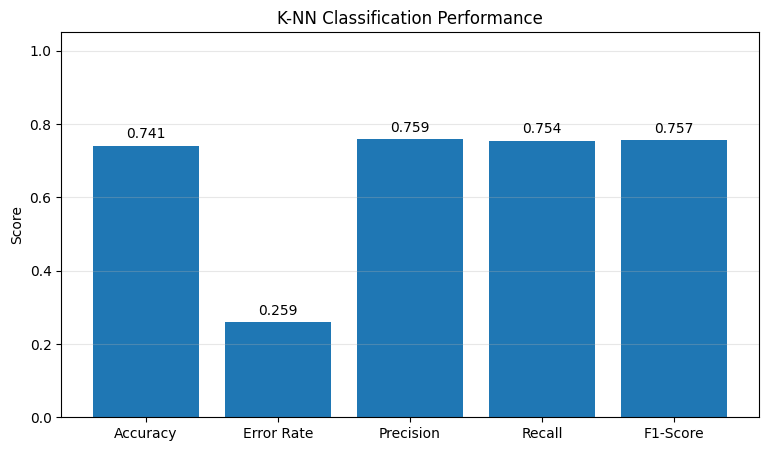

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(url, sep=";")

df["quality"] = (df["quality"] >= 6).astype(int)

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("K-NN Performance Evaluation")
print("===========================")
print(f"Accuracy   : {accuracy:.4f}")
print(f"Error Rate : {error_rate:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1:.4f}")

metrics = ["Accuracy", "Error Rate", "Precision", "Recall", "F1-Score"]
values = [accuracy, error_rate, precision, recall, f1]

plt.figure(figsize=(9, 5))

bars = plt.bar(metrics, values)

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("K-NN Classification Performance")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

9 ) Association Rule Mining

 Implement the Association Rule Mining algorithm (e.g., Apriori) to find
frequent itemsets.

Dataset Shape: (541909, 8)

First 5 Records:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Total Transactions: 20136
Transaction Matrix Shape: (20136, 4077)

Top 20 Frequent Itemsets
                           Itemset  support
WHITE H

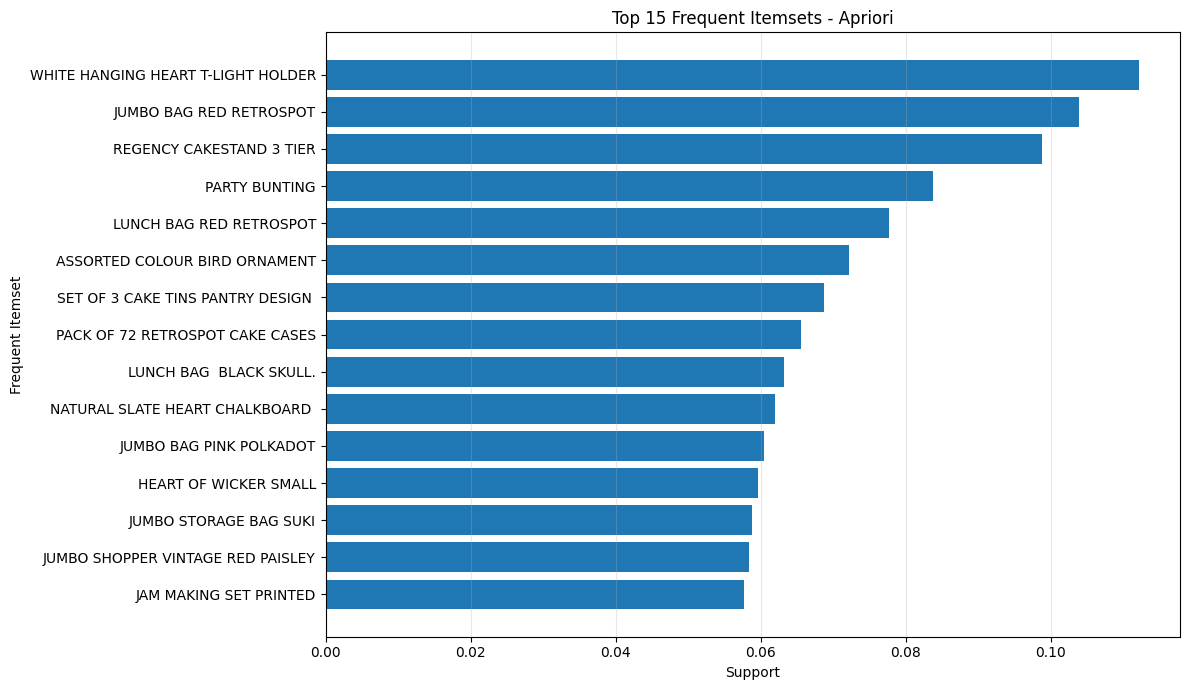

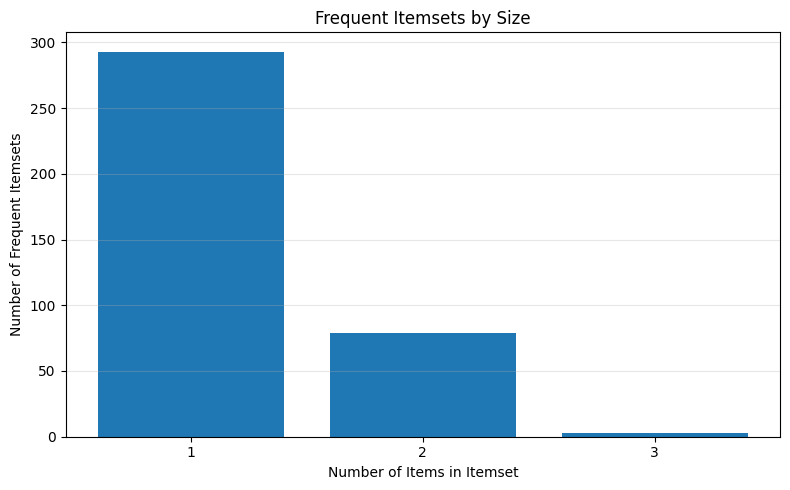


Frequent Itemset Summary
1-itemset(s): 293
2-itemset(s): 79
3-itemset(s): 3


In [18]:
!pip install mlxtend -q

import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
import io

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    file_name = [f for f in z.namelist() if f.endswith(".xlsx")][0]
    df = pd.read_excel(z.open(file_name))

print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())

df = df.dropna(subset=["InvoiceNo", "Description"])

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["Description"] = df["Description"].astype(str)

df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[df["Quantity"] > 0]

transactions = (
    df.groupby("InvoiceNo")["Description"]
    .apply(lambda x: list(set(x)))
    .tolist()
)

transactions = [t for t in transactions if len(t) > 0]

print("\nTotal Transactions:", len(transactions))

encoder = TransactionEncoder()

encoded = encoder.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded,
    columns=encoder.columns_
)

print("Transaction Matrix Shape:", basket.shape)

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets["Itemset Size"] = (
    frequent_itemsets["itemsets"].apply(len)
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

result = frequent_itemsets.head(20).copy()

result["Itemset"] = result["itemsets"].apply(
    lambda x: ", ".join(sorted(x))
)

print("\nTop 20 Frequent Itemsets")
print("========================")
print(
    result[["Itemset", "support"]].to_string(index=False)
)

top = frequent_itemsets.head(15).copy()

top["Itemset"] = top["itemsets"].apply(
    lambda x: ", ".join(sorted(x))
)

plt.figure(figsize=(12, 7))

plt.barh(
    top["Itemset"][::-1],
    top["support"][::-1]
)

plt.xlabel("Support")
plt.ylabel("Frequent Itemset")
plt.title("Top 15 Frequent Itemsets - Apriori")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

itemset_counts = (
    frequent_itemsets["Itemset Size"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    itemset_counts.index.astype(str),
    itemset_counts.values
)

plt.xlabel("Number of Items in Itemset")
plt.ylabel("Number of Frequent Itemsets")
plt.title("Frequent Itemsets by Size")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFrequent Itemset Summary")
print("========================")

for size, count in itemset_counts.items():
    print(f"{size}-itemset(s): {count}")

Generate association rules from the frequent itemsets and calculate their
support and confidence.

Dataset Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Number of Transactions: 20136
Transaction Matrix:


,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Frequent Itemsets:


,support,itemsets,Itemset Size
273,0.112237,(WHITE HANGING HEART T-LIGHT HOLDER),1
102,0.103894,(JUMBO BAG RED RETROSPOT),1
197,0.098778,(REGENCY CAKESTAND 3 TIER),1
157,0.083731,(PARTY BUNTING),1
127,0.077672,(LUNCH BAG RED RETROSPOT),1
15,0.072259,(ASSORTED COLOUR BIRD ORNAMENT),1
218,0.068782,(SET OF 3 CAKE TINS PANTRY DESIGN ),1
149,0.065554,(PACK OF 72 RETROSPOT CAKE CASES),1
120,0.063220,(LUNCH BAG BLACK SKULL.),1
139,0.062028,(NATURAL SLATE HEART CHALKBOARD ),1



Generated Association Rules:


,antecedents,consequents,support,confidence,lift
136,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.026917,0.904841,17.950627
135,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.026917,0.856240,16.173782
23,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031436,0.826371,16.393893
147,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,0.020511,0.801942,7.718881
141,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.020262,0.801572,15.141133
121,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029748,0.781984,14.771141
143,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",GREEN REGENCY TEACUP AND SAUCER,0.020262,0.777143,15.417289
26,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.038141,0.756650,14.292598
27,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038141,0.720450,14.292598
21,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027116,0.720317,15.886413



Top 10 Rules:


,antecedents,consequents,support,confidence,lift
136,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.026917,0.904841,17.950627
135,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.026917,0.856240,16.173782
23,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031436,0.826371,16.393893
147,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI",JUMBO BAG RED RETROSPOT,0.020511,0.801942,7.718881
141,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.020262,0.801572,15.141133
121,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029748,0.781984,14.771141
143,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",GREEN REGENCY TEACUP AND SAUCER,0.020262,0.777143,15.417289
26,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.038141,0.756650,14.292598
27,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.038141,0.720450,14.292598
21,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.027116,0.720317,15.886413


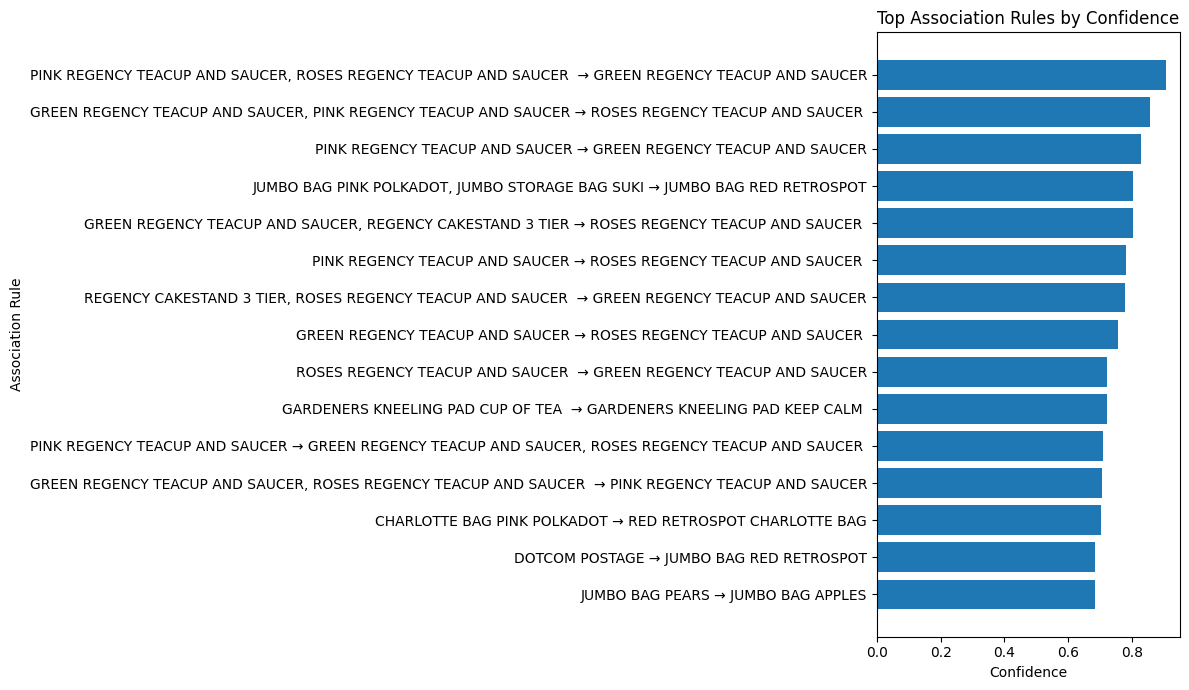

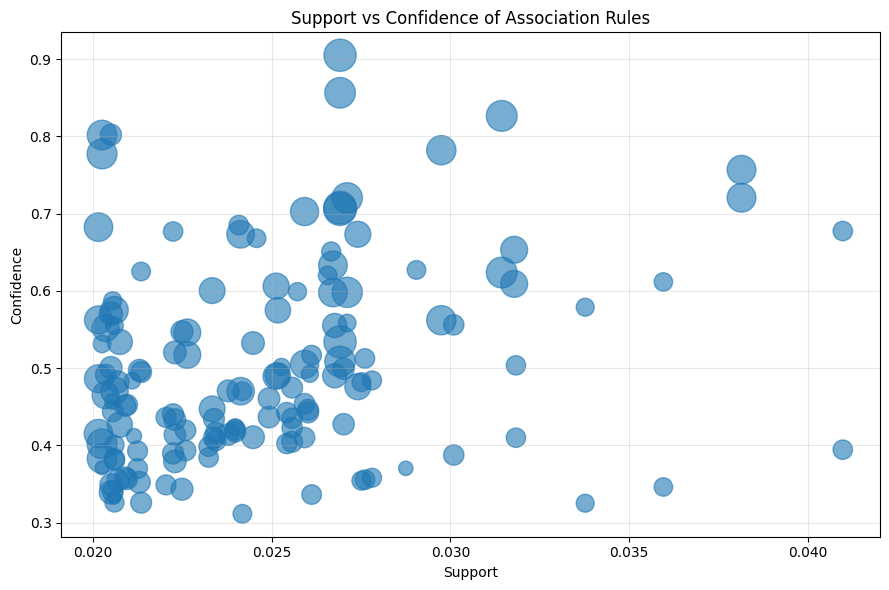

In [19]:
!pip install mlxtend -q

import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
import io
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))

file_name = [f for f in z.namelist() if f.endswith(".xlsx")][0]
df = pd.read_excel(z.open(file_name))

print("Dataset Shape:", df.shape)
display(df.head())

df = df.dropna(subset=["InvoiceNo", "Description"])

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["Description"] = df["Description"].astype(str)

df = df[~df["InvoiceNo"].str.startswith("C")]

df = df[df["Quantity"] > 0]

transactions = (
    df.groupby("InvoiceNo")["Description"]
    .apply(lambda x: list(set(x)))
    .tolist()
)

transactions = [t for t in transactions if len(t) > 0]

print("Number of Transactions:", len(transactions))

encoder = TransactionEncoder()

encoded_data = encoder.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded_data,
    columns=encoder.columns_
)

print("Transaction Matrix:")
display(basket.head())

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets["Itemset Size"] = frequent_itemsets["itemsets"].apply(len)

print("Frequent Itemsets:")
display(frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(20))

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules["antecedents"] = rules["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules["consequents"] = rules["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules = rules.sort_values(
    by="confidence",
    ascending=False
)

print("\nGenerated Association Rules:")
display(rules.head(20))

print("\nTop 10 Rules:")
display(rules.head(10))

top_rules = rules.head(15).copy()

top_rules["Rule"] = (
    top_rules["antecedents"]
    + " → "
    + top_rules["consequents"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_rules["Rule"][::-1],
    top_rules["confidence"][::-1]
)

plt.xlabel("Confidence")
plt.ylabel("Association Rule")
plt.title("Top Association Rules by Confidence")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"] * 30,
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence of Association Rules")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Interpret and analyze the discovered association rules.

Top 15 Association Rules


,antecedents,consequents,Support (%),Confidence (%),lift,Interpretation
137,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,2.691696,70.572917,18.551648,Positive Association
138,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",2.691696,70.757180,18.551648,Positive Association
139,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",2.691696,53.399015,17.950627,Positive Association
136,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,2.691696,90.484140,17.950627,Positive Association
23,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,3.143623,82.637076,16.393893,Positive Association
24,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,3.143623,62.364532,16.393893,Positive Association
140,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",2.691696,50.844278,16.173782,Positive Association
135,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,2.691696,85.624013,16.173782,Positive Association
22,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,2.711561,59.802848,15.886413,Positive Association
21,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,2.711561,72.031662,15.886413,Positive Association


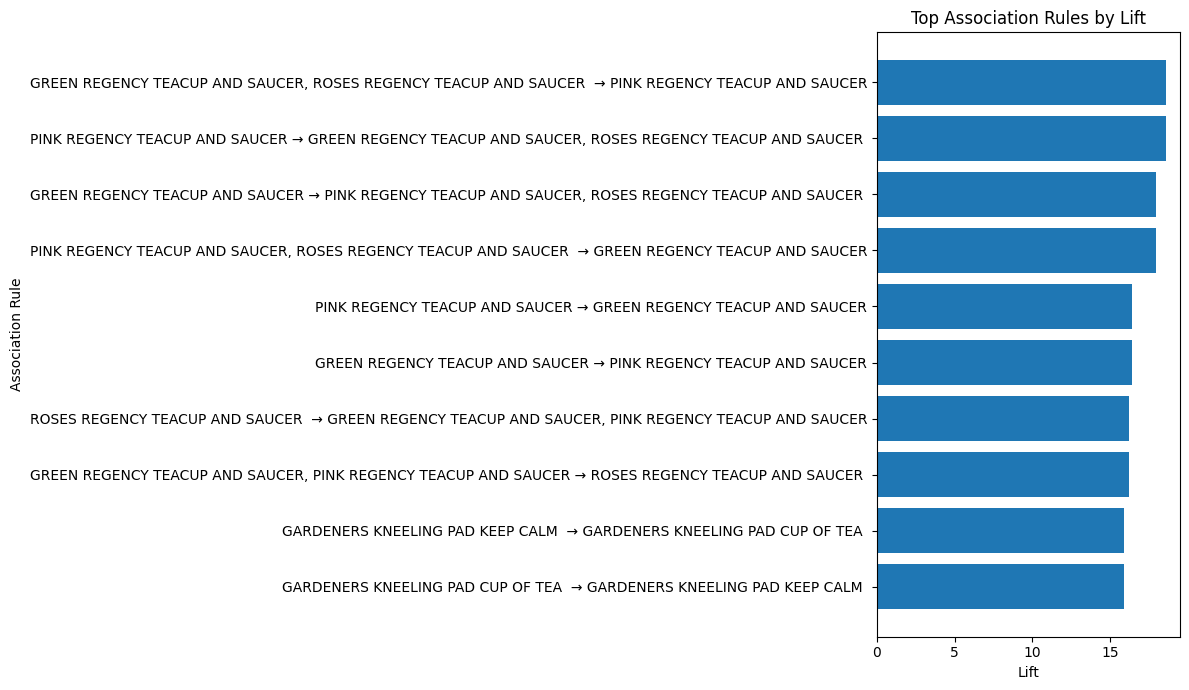

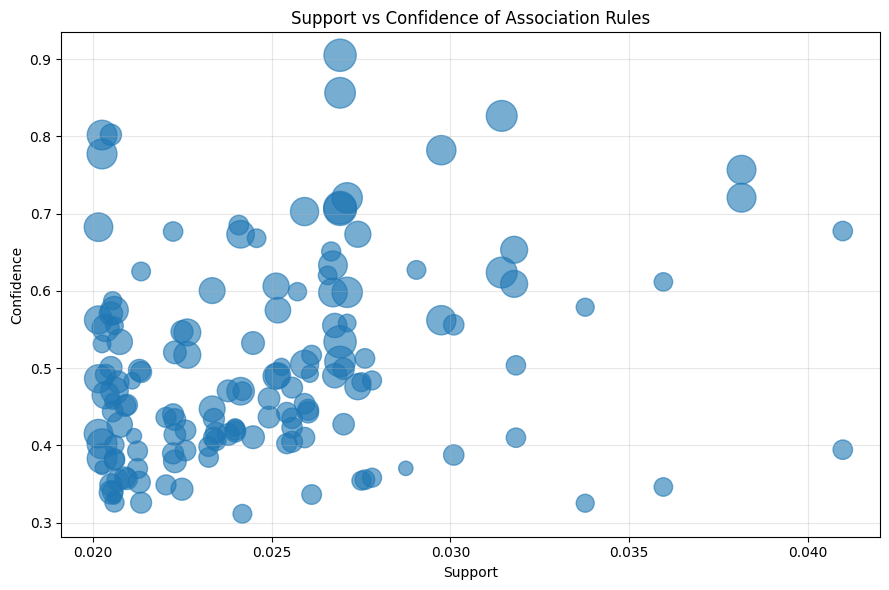


ANALYSIS OF DISCOVERED RULES
--------------------------------
Total Association Rules: 151
Positive Association Rules: 151
Negative Association Rules: 0

Strongest Rule:


,antecedents,consequents,Support (%),Confidence (%),lift,Interpretation
137,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,2.691696,70.572917,18.551648,Positive Association



Interpretation:
Support shows how frequently the item combination occurs.
Confidence shows how reliably the consequent is purchased with the antecedent.
Lift greater than 1 indicates a positive association.
Higher lift indicates a stronger relationship between the items.


In [20]:
!pip install mlxtend -q

import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests
import io
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))

file_name = [f for f in z.namelist() if f.endswith(".xlsx")][0]
df = pd.read_excel(z.open(file_name))

df = df.dropna(subset=["InvoiceNo", "Description"])
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["Description"] = df["Description"].astype(str)

df = df[~df["InvoiceNo"].str.startswith("C")]
df = df[df["Quantity"] > 0]

transactions = (
    df.groupby("InvoiceNo")["Description"]
    .apply(lambda x: list(set(x)))
    .tolist()
)

transactions = [t for t in transactions if len(t) > 0]

encoder = TransactionEncoder()
encoded = encoder.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded,
    columns=encoder.columns_
)

frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

rules = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
]

rules["antecedents"] = rules["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules["consequents"] = rules["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules["Support (%)"] = rules["support"] * 100
rules["Confidence (%)"] = rules["confidence"] * 100

def interpret_lift(lift):
    if lift > 1:
        return "Positive Association"
    elif lift < 1:
        return "Negative Association"
    else:
        return "No Association"

rules["Interpretation"] = rules["lift"].apply(interpret_lift)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

print("Top 15 Association Rules")
display(
    rules[
        [
            "antecedents",
            "consequents",
            "Support (%)",
            "Confidence (%)",
            "lift",
            "Interpretation"
        ]
    ].head(15)
)

best_rules = rules.head(10).copy()

best_rules["Rule"] = (
    best_rules["antecedents"]
    + " → "
    + best_rules["consequents"]
)

plt.figure(figsize=(12, 7))

plt.barh(
    best_rules["Rule"][::-1],
    best_rules["lift"][::-1]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Association Rules by Lift")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

plt.scatter(
    rules["support"],
    rules["confidence"],
    s=rules["lift"] * 30,
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence of Association Rules")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nANALYSIS OF DISCOVERED RULES")
print("--------------------------------")

positive = (rules["lift"] > 1).sum()
negative = (rules["lift"] < 1).sum()

print("Total Association Rules:", len(rules))
print("Positive Association Rules:", positive)
print("Negative Association Rules:", negative)

print("\nStrongest Rule:")
display(
    rules[
        [
            "antecedents",
            "consequents",
            "Support (%)",
            "Confidence (%)",
            "lift",
            "Interpretation"
        ]
    ].head(1)
)

print("\nInterpretation:")
print("Support shows how frequently the item combination occurs.")
print("Confidence shows how reliably the consequent is purchased with the antecedent.")
print("Lift greater than 1 indicates a positive association.")
print("Higher lift indicates a stronger relationship between the items.")

10 )Demo of OpenAI/TensorFlow Tools

TensorFlow Version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


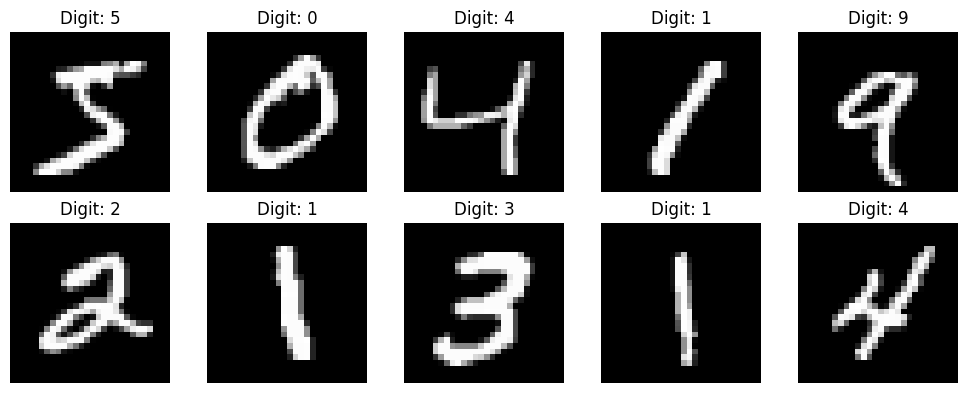

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9065 - loss: 0.3261 - val_accuracy: 0.9546 - val_loss: 0.1547
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9545 - loss: 0.1549 - val_accuracy: 0.9688 - val_loss: 0.1128
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9649 - loss: 0.1149 - val_accuracy: 0.9708 - val_loss: 0.0999
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9706 - loss: 0.0939 - val_accuracy: 0.9730 - val_loss: 0.0897
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9756 - loss: 0.0791 - val_accuracy: 0.9762 - val_loss: 0.0810

Test Loss: 0.07130544632673264
Test Accuracy: 0.9783999919891357


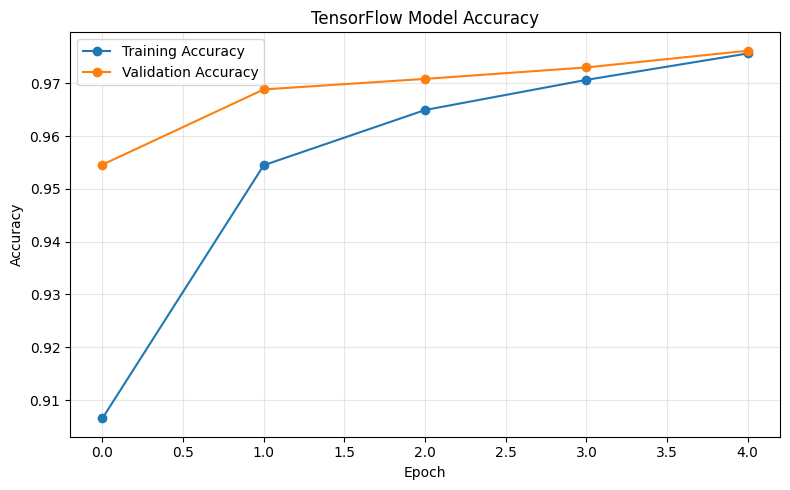

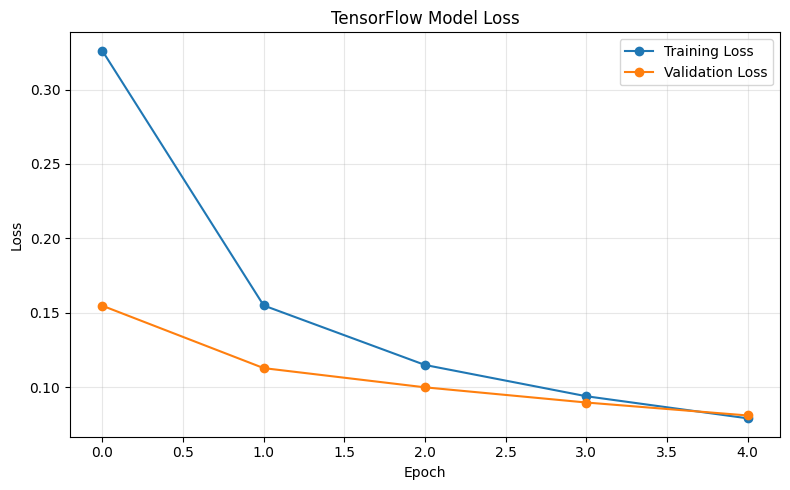

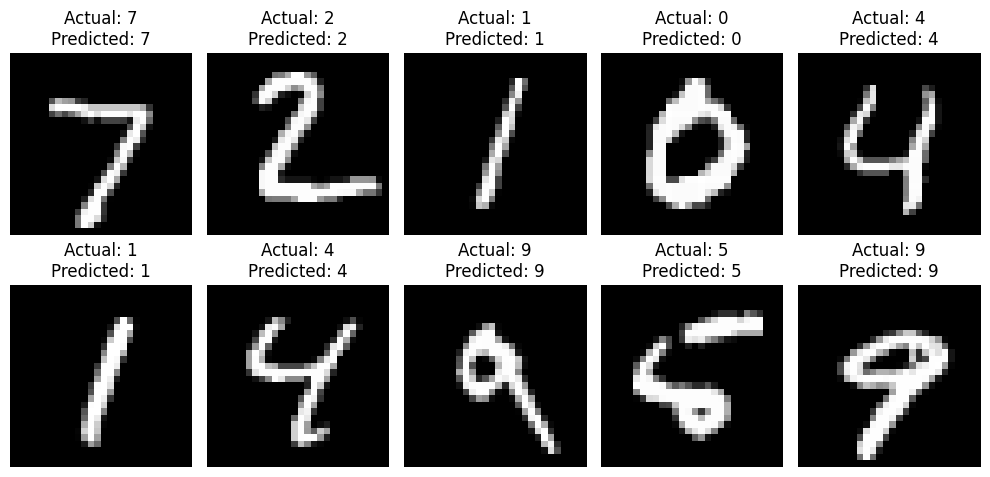


Correct Predictions: 9784
Total Test Samples: 10000
Prediction Accuracy: 0.9784


In [21]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TensorFlow Model Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Model Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

predictions = model.predict(x_test, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

correct = np.sum(predicted_labels == y_test)
total = len(y_test)

print("\nCorrect Predictions:", correct)
print("Total Test Samples:", total)
print("Prediction Accuracy:", correct / total)

 Perform a demonstration or mini-project showcasing the capabilities of the
tools.

TensorFlow Version: 2.20.0
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


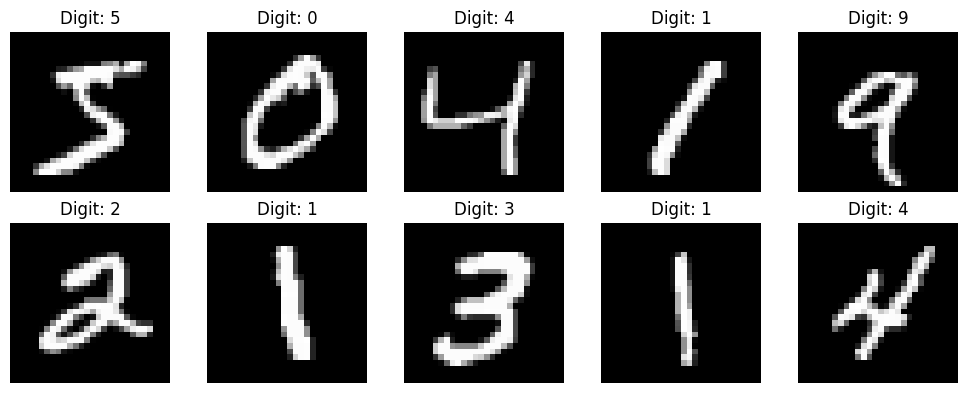

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9066 - loss: 0.3244 - val_accuracy: 0.9530 - val_loss: 0.1651
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9516 - loss: 0.1616 - val_accuracy: 0.9638 - val_loss: 0.1222
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9640 - loss: 0.1196 - val_accuracy: 0.9688 - val_loss: 0.1034
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9704 - loss: 0.0954 - val_accuracy: 0.9673 - val_loss: 0.1044
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9760 - loss: 0.0801 - val_accuracy: 0.9761 - val_loss: 0.0846

Test Loss: 0.07984446734189987
Test Accuracy: 0.9751999974250793


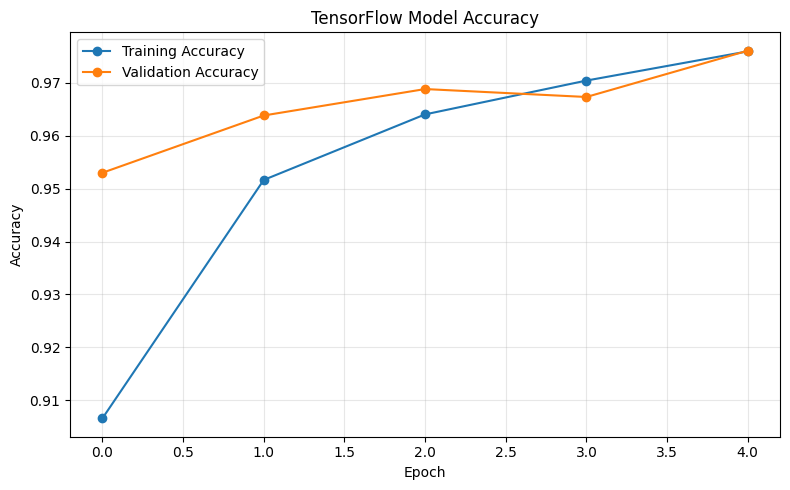

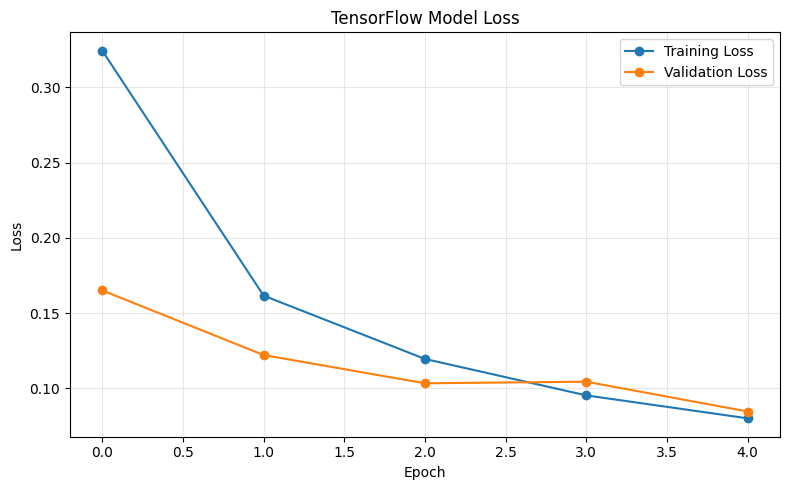

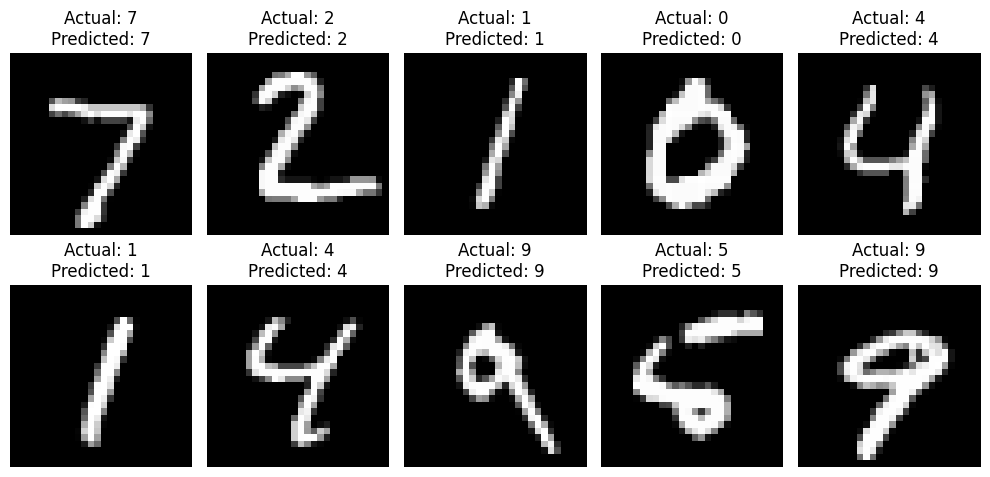


Correct Predictions: 9752
Total Test Samples: 10000
Prediction Accuracy: 0.9752


In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TensorFlow Model Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Model Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

predictions = model.predict(x_test, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"Actual: {y_test[i]}\nPredicted: {predicted_labels[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

correct = np.sum(predicted_labels == y_test)
total = len(y_test)

print("\nCorrect Predictions:", correct)
print("Total Test Samples:", total)
print("Prediction Accuracy:", correct / total)